# Data processing

In [1]:
!echo $$

895949


In [2]:
from dotenv import load_dotenv
import os 
load_dotenv()


WANDB_API_KEY = os.getenv("WANDB_API_KEY")

In [3]:
BASE_PATH = 'data/Dataset/'
TRAIN_PATH = BASE_PATH + 'Train/'
VAL_PATH = BASE_PATH + 'Val/'
TEST_PATH = BASE_PATH + 'Test/'

In [4]:
TEST_PATH

'data/Dataset/Test/'

In [35]:
from torchvision import datasets, transforms


train_transform = transforms.Compose([
    transforms.Resize((256, 256)), 
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomRotation(15),  
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),  
    transforms.RandomApply([transforms.GaussianBlur(3, sigma=(0.1, 2.0))], p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1) 
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root = TRAIN_PATH, transform = train_transform)
val_dataset = datasets.ImageFolder(root = VAL_PATH, transform = val_test_transform)


In [36]:
train_dataset[0]

(tensor([[[-2.0494, -2.0494, -2.0494,  ..., -2.0494, -2.0494, -2.0494],
          [-2.0494, -2.0494, -2.0494,  ..., -2.0494, -2.0494, -2.0494],
          [-2.0494, -2.0494, -2.0494,  ..., -2.0494, -2.0494, -2.0494],
          ...,
          [-2.0494, -2.0494, -2.0494,  ..., -2.0494, -2.0494, -2.0494],
          [-2.0494, -2.0494, -2.0494,  ..., -2.0494, -2.0494, -2.0494],
          [-2.0494, -2.0494, -2.0494,  ..., -2.0494, -2.0494, -2.0494]],
 
         [[-1.9657, -1.9657, -1.9657,  ..., -1.9657, -1.9657, -1.9657],
          [-1.9657, -1.9657, -1.9657,  ..., -1.9657, -1.9657, -1.9657],
          [-1.9657, -1.9657, -1.9657,  ..., -1.9657, -1.9657, -1.9657],
          ...,
          [-1.9657, -1.9657, -1.9657,  ..., -1.9657, -1.9657, -1.9657],
          [-1.9657, -1.9657, -1.9657,  ..., -1.9657, -1.9657, -1.9657],
          [-1.9657, -1.9657, -1.9657,  ..., -1.9657, -1.9657, -1.9657]],
 
         [[-1.7347, -1.7347, -1.7347,  ..., -1.7347, -1.7347, -1.7347],
          [-1.7347, -1.7347,

In [37]:
train_dataset[0][0].shape

torch.Size([3, 224, 224])

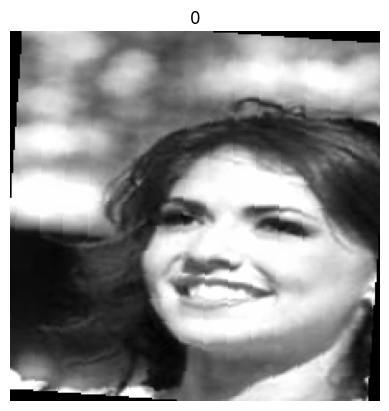

In [38]:
import matplotlib.pyplot as plt



def show_image(datapoint): 

    image, label = datapoint
    plt.imshow(image[0], cmap='gray')
    plt.title(label)
    plt.axis('off')
    plt.show()

show_image(train_dataset[0])

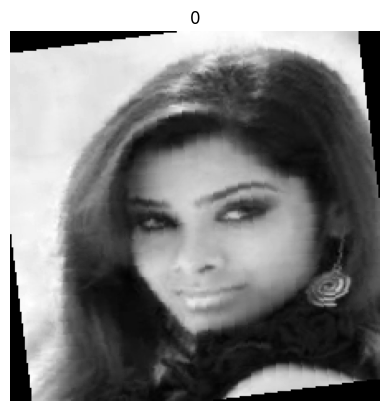

In [39]:
show_image(train_dataset[60])

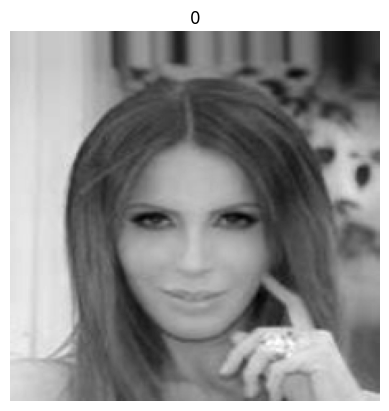

In [40]:
show_image(val_dataset[120])

# Datamodule 

In [10]:
import lightning as pl 
from torch.utils.data import random_split, DataLoader, ConcatDataset 


class GenderDataModule(pl.LightningDataModule):
    def __init__(self, train_dataset, val_dataset, batch_size=32, val_test_ratio = 0.2):
        super().__init__()
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.batch_size = batch_size
        self.val_test_ratio = val_test_ratio

    def setup(self, stage=None):
        if stage == 'fit' or stage is None:
            self.train_data = ConcatDataset([self.train_dataset, self.val_dataset])
            self.val_data = self.val_dataset
            
        elif stage == 'test':
            test_size = int(len(self.val_dataset) * self.val_test_ratio)
            val_size = len(self.val_dataset) - test_size

            self.val_data, self.test_data = random_split(self.val_dataset, [val_size, test_size])

    def train_dataloader(self):
        return DataLoader(self.train_data, batch_size=self.batch_size, shuffle=True, num_workers=4)

    def val_dataloader(self):
        return DataLoader(self.val_data, batch_size=self.batch_size, num_workers=4)

    def test_dataloader(self):
        return DataLoader(self.test_data, batch_size=self.batch_size, num_workers=4)


# Define model 

In [11]:
import torch.nn as nn 
import torch.optim as optim
import torchvision.models as models


class GenderPretrained: 

    @staticmethod
    def create_resnet18(num_classes=2, pretrained=True):
        model = models.resnet18(pretrained=pretrained)
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        return model

    @staticmethod
    def create_resnet50(num_classes=2, pretrained=True):
        model = models.resnet50(pretrained=pretrained)
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        return model
    

    @staticmethod
    def create_efficientnet(num_classes=2, pretrained=True):
        model = models.efficientnet_b0(pretrained=pretrained)
        num_features = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        return model

    @staticmethod 
    def create_vision_transformer(num_classes=2, pretrained=True):
        """Vision Transformer - State-of-the-art cho nhiều tác vụ computer vision"""
        model = models.vit_b_16(pretrained=pretrained)
        num_features = model.heads.head.in_features
        model.heads.head = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        return model


    @staticmethod
    def create_efficientnet_v2(num_classes=2, pretrained=True):
        """EfficientNetV2 - Cải tiến của EfficientNet với training speed nhanh hơn"""
        model = models.efficientnet_v2_s(pretrained=pretrained)
        num_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        return model
    
    @staticmethod
    def create_efficientnet_v2_l(num_classes=2, pretrained=True):
        """EfficientNet V2 Large - Mô hình lớn hơn"""
        model = models.efficientnet_v2_l(pretrained=pretrained)
        num_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(num_features, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        return model

In [12]:
from torchmetrics import Accuracy, F1Score, Precision, Recall


def get_model(model_name: str, num_classes: int = 2, pretrained: bool = True):
    model_map = {
        'resnet18': GenderPretrained.create_resnet18,
        'resnet50': GenderPretrained.create_resnet50,
        'efficientnet': GenderPretrained.create_efficientnet,
        'vision_transformer': GenderPretrained.create_vision_transformer,
        'efficientnet_v2': GenderPretrained.create_efficientnet_v2, 
        'efficientnet_v2_l': GenderPretrained.create_efficientnet_v2_l
    }


    if model_name not in model_map:
        available_models = list(model_map.keys())
        raise ValueError(f"Model {model_name} not recognized. Choose from: {available_models}")
    
    return model_map[model_name](num_classes, pretrained)

    


class GenderModule(pl.LightningModule):
    def __init__(self, model_name: str):
        super().__init__()
        self.model = get_model(model_name)

        self.criterion = nn.CrossEntropyLoss()

        self.train_acc = Accuracy(task = 'multiclass', num_classes=2)
        self.val_acc = Accuracy(task = 'multiclass', num_classes=2)
        self.test_acc = Accuracy(task = 'multiclass', num_classes=2)

        self.val_f1 = F1Score(task = 'multiclass', num_classes=2)
        self.val_precision = Precision(task = 'multiclass', num_classes=2)
        self.val_recall = Recall(task = 'multiclass', num_classes=2)

        self.test_f1 = F1Score(task = 'multiclass', num_classes=2)
        self.test_precision = Precision(task = 'multiclass', num_classes=2)
        self.test_recall = Recall(task = 'multiclass', num_classes=2)
        self.save_hyperparameters()

        

    def forward(self, x):
        return self.model(x)
    


    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        acc = self.train_acc(y_hat, y)
        self.log('train_loss', loss)

        self.log('train_acc', acc, on_step=True, prog_bar=True)
        self.log('train_acc_epoch', self.train_acc, on_epoch=True, prog_bar=True)

        return loss
    

    def validation_step(self, batch, batch_idx):
        x, y = batch 
        y_hat = self(x)
        loss = self.criterion(y_hat, y)

        acc = self.val_acc(y_hat, y)
        f1 = self.val_f1(y_hat, y)
        precision = self.val_precision(y_hat, y)
        recall = self.val_recall(y_hat, y)

        self.log('val_loss', loss, on_step=True, prog_bar=True)
        self.log('val_acc', acc, on_step=True, prog_bar=True)
        self.log('val_f1', f1, on_step=True, prog_bar=True)
        self.log('val_precision', precision, on_step=True, prog_bar=True)
        self.log('val_recall', recall, on_step=True, prog_bar=True)



    def test_step(self, batch, batch_idx):
        x, y = batch 
        y_hat = self(x)
        loss = self.criterion(y_hat, y)

        acc = self.test_acc(y_hat, y)
        f1 = self.test_f1(y_hat, y)
        precision = self.test_precision(y_hat, y)
        recall = self.test_recall(y_hat, y)

        self.log('test_loss', loss, on_step=True, prog_bar=True)
        self.log('test_acc', acc, on_step=True, prog_bar=True)
        self.log('test_f1', f1, on_step=True, prog_bar=True)
        self.log('test_precision', precision, on_step=True, prog_bar=True)
        self.log('test_recall', recall, on_step=True, prog_bar=True)



    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=1e-4, weight_decay=1e-2)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_acc'
            }
        }



In [13]:
config = {
    'model_name': 'efficientnet_v2',
    'batch_size': 32,
    'max_epochs': 10,
    'gpus': 1,
    'num_workers': 4,
    'val_test_ratio': 0.2,
}

In [14]:
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
import wandb


wandb.login(
  key = WANDB_API_KEY
)
model_name = config['model_name']
wandb_logger = WandbLogger(
      name = config['model_name'],
      project = "Gender Classification",
      log_model = True
)

model_checkpoint = ModelCheckpoint(
      dirpath='checkpoints/',
      filename="{model_name}-{epoch}-{val_loss:.2f}",
      monitor='val_loss',
      save_top_k=3,
      mode='min',
      save_weights_only=True
)

early_stopping = EarlyStopping(
      monitor='val_loss',
      patience=3,
      verbose=False,
      mode='min'
)

trainer = pl.Trainer(
    accelerator = "cuda",
    devices = config['gpus'],
    max_epochs = config['max_epochs'],
    callbacks = [early_stopping, model_checkpoint],
    logger = wandb_logger
)

wandb: Currently logged in as: theseventeengv (trungviet17) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/thviet/.local/lib/python3.11/site-packages/ipy ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [15]:
!echo $$

model = GenderModule(config['model_name'])
data_module = GenderDataModule(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=config['batch_size'],
    val_test_ratio=config['val_test_ratio']
)


trainer.fit(model, data_module)

897803


/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.or

/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /workspace/thviet/trungnnv/AIT3002-image-processing/final/gender_classification/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name           | Type                | Params | Mode 
----------------------------------------------------------------
0  | model          | EfficientNet        | 20.8 M | train
1  | criterion      | CrossEntropyLoss    | 0      | train
2  | train_acc      | MulticlassAccuracy  | 0      | train
3  | val_acc        | MulticlassAccuracy  | 0      | train
4  | test_acc       | MulticlassAccuracy  | 0      | train
5  | val_f1         | MulticlassF1Score   | 0      | train
6  | val_precision  | MulticlassPrecision | 0      | train
7  | val_recall     | MulticlassRecall    | 0      | train
8  | test_f1        | MulticlassF1Score   | 0      | train
9  | test_precision | Mu

Epoch 9: 100%|██████████| 282/282 [00:43<00:00,  6.55it/s, v_num=ichi, train_acc=1.000, train_acc_epoch_step=1.000, val_loss_step=0.000123, val_acc_step=1.000, val_f1_step=1.000, val_precision_step=1.000, val_recall_step=1.000, val_loss_epoch=0.00213, val_acc_epoch=0.999, val_f1_epoch=0.999, val_precision_epoch=0.999, val_recall_epoch=0.999, train_acc_epoch_epoch=0.997]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 282/282 [00:43<00:00,  6.42it/s, v_num=ichi, train_acc=1.000, train_acc_epoch_step=1.000, val_loss_step=0.000123, val_acc_step=1.000, val_f1_step=1.000, val_precision_step=1.000, val_recall_step=1.000, val_loss_epoch=0.00213, val_acc_epoch=0.999, val_f1_epoch=0.999, val_precision_epoch=0.999, val_recall_epoch=0.999, train_acc_epoch_epoch=0.997]


In [16]:
trainer.test(model, data_module)
wandb.finish()

/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/thviet/.local/lib/python3.11/site-packages/ipy ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 19.08it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_acc_epoch       │            1.0            │
│       test_f1_epoch       │            1.0            │
│      test_loss_epoch      │  0.00045061978744342923   │
│   test_precision_epoch    │            1.0            │
│     test_recall_epoch     │            1.0            │
└───────────────────────────┴───────────────────────────┘

epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇█
test_acc_epoch,▁
test_acc_step,▁▁▁▁▁▁▁
test_f1_epoch,▁
test_f1_step,▁▁▁▁▁▁▁
test_loss_epoch,▁
test_loss_step,▂▄▁▃█▆▁
test_precision_epoch,▁
test_precision_step,▁▁▁▁▁▁▁
test_recall_epoch,▁
test_recall_step,▁▁▁▁▁▁▁


In [47]:
import torch 
from PIL import Image
from tqdm import tqdm
from pathlib import Path
import os
import pandas as pd




model_path = 'checkpoints/model_name=0-epoch=9-val_loss=0.00.ckpt'
model = GenderModule.load_from_checkpoint(model_path)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.eval()

def process_image(img_path):
    img = Image.open(img_path).convert('RGB')
    return val_test_transform(img).unsqueeze(0).to(device)

test_files = sorted([f for f in os.listdir(TEST_PATH) if f.endswith(('.jpg', '.jpeg', '.png'))])

results = []

with torch.no_grad():
    for file_name in tqdm(test_files, desc="testing"):
        img_id = Path(file_name).stem

        img_path = os.path.join(TEST_PATH, file_name)

        img = process_image(img_path)
        pred = model(img)
        pred_class = torch.argmax(pred, dim=1).item()

     
        if pred_class == 0:
            pred_class = 1 
        elif pred_class == 1:
            pred_class = 0

        results.append({
            "ID": img_id,
            "Label": pred_class
        })


df = pd.DataFrame(results)

csv_path = "gender_predictions_1.csv"
df.to_csv(csv_path, index=False)


print(f"Predictions saved to {csv_path}")

/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
testing: 100%|██████████| 1000/1000 [00:29<00:00, 33.38it/s]

Predictions saved to gender_predictions_1.csv


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      1000 non-null   object
 1   Label   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB
